# Cyber Risk Control ROI + Sensitivity Analysis

This notebook evaluates how cyber control effectiveness changes financial outcomes.

It extends scenario-based modeling by:
- Measuring ROI stability
- Testing sensitivity to key variables
- Identifying key drivers of risk reduction

Goal:
Understand not just *if* a control works, but *why* it works.

In [1]:
# ======================
# 03 — CONTROL ROI ANALYSIS
# ======================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
# ======================
# CONFIGURATION
# ======================

SIMULATIONS = 10000
LOSS_MEAN = 14.5
LOSS_SIGMA = 0.7
BASE_TEF = (1, 3, 6)
CONTROL_COST = 1_000_000

In [3]:
# ======================
# RISK ENGINE
# ======================

def simulate_ale(tef_range, loss_mean, loss_sigma, n=10000):
    tef = np.random.triangular(*tef_range, n)
    loss = np.random.lognormal(loss_mean, loss_sigma, n)
    return tef * loss

In [4]:
# ======================
# CONTROL FUNCTION
# ======================

def apply_control(tef_range, reduction):
    return tuple(x * (1 - reduction) for x in tef_range)

In [5]:
# ======================
# BASELINE
# ======================

baseline = simulate_ale(BASE_TEF, LOSS_MEAN, LOSS_SIGMA, SIMULATIONS)
baseline_median = np.percentile(baseline, 50)

In [6]:
# ======================
# CONTROL SCENARIOS
# ======================

control_levels = [0.0, 0.2, 0.4, 0.6, 0.8]

results = []

for c in control_levels:
    controlled_tef = apply_control(BASE_TEF, c)
    
    controlled_ale = simulate_ale(
        controlled_tef,
        LOSS_MEAN,
        LOSS_SIGMA,
        SIMULATIONS
    )
    
    controlled_median = np.percentile(controlled_ale, 50)
    
    risk_reduction = baseline_median - controlled_median
    roi = (risk_reduction - CONTROL_COST) / CONTROL_COST
    
    results.append({
        "Control Reduction": c,
        "Risk Reduction ($)": risk_reduction,
        "ROI": roi
    })

df = pd.DataFrame(results)
print(df)

   Control Reduction  Risk Reduction ($)       ROI
0                0.0        5.538519e+04 -0.944615
1                0.2        1.190936e+06  0.190936
2                0.4        2.509547e+06  1.509547
3                0.6        3.767400e+06  2.767400
4                0.8        5.044256e+06  4.044256


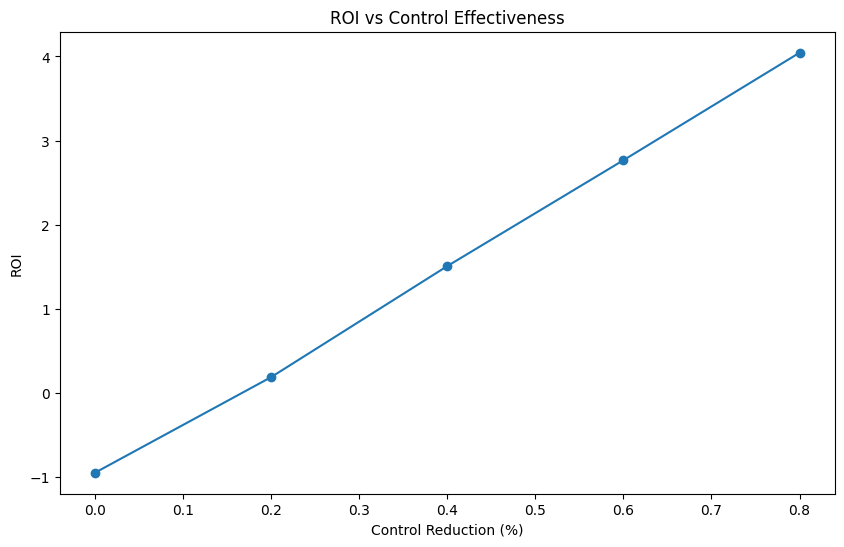

In [7]:
# ======================
# ROI VISUALIZATION
# ======================

plt.figure(figsize=(10,6))
plt.plot(df["Control Reduction"], df["ROI"], marker='o')
plt.title("ROI vs Control Effectiveness")
plt.xlabel("Control Reduction (%)")
plt.ylabel("ROI")
plt.show()

## Key Insight

- ROI is highly sensitive to control effectiveness
- Small improvements in control strength significantly impact financial return
- Cyber investments should be evaluated as *range-based decisions*, not point estimates

Implication:
Security investment decisions should incorporate uncertainty and sensitivity, not static ROI values.

In [9]:
print("\n=== FINAL SUMMARY: CONTROL ROI ===")
print(df)


=== FINAL SUMMARY: CONTROL ROI ===
   Control Reduction  Risk Reduction ($)       ROI
0                0.0        5.538519e+04 -0.944615
1                0.2        1.190936e+06  0.190936
2                0.4        2.509547e+06  1.509547
3                0.6        3.767400e+06  2.767400
4                0.8        5.044256e+06  4.044256


In [10]:
print("\n=== MASTER INSIGHT ===")

best_row = df.loc[df["ROI"].idxmax()]

print(f"Best Control Level: {best_row['Control Reduction']}")
print(f"Expected Risk Reduction: ${best_row['Risk Reduction ($)']:,.0f}")
print(f"ROI: {best_row['ROI']:.2f}")


=== MASTER INSIGHT ===
Best Control Level: 0.8
Expected Risk Reduction: $5,044,256
ROI: 4.04
